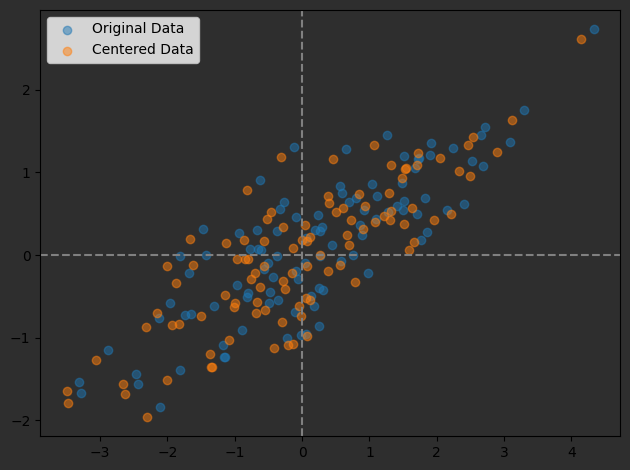

In [14]:
import os

import matplotlib.pyplot as plt
import numpy as np

# Generate a synthetic dataset for PCA
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]  # covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

# Compute the mean and center the data
mu = np.mean(X, axis=0)
X_centered = X - mu

# Compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
order = eig_vals.argsort()[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

# Project data onto the first principal component
X_proj = X_centered @ eig_vecs[:, :2]

# Start with the centered data plot
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Original Data")
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label="Centered Data")
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.legend()
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/centered_data.png")


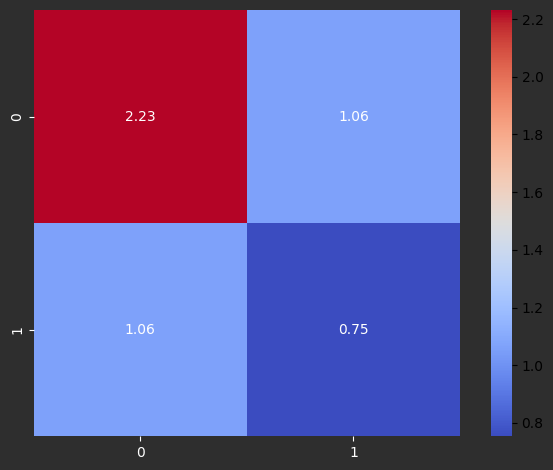

In [23]:
import seaborn as sns

# Plot covariance matrix heatmap
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
plt.tight_layout()
plt.tight_layout()
ax.tick_params(colors='white')
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Covariance-Matrix-Heatmap.png")

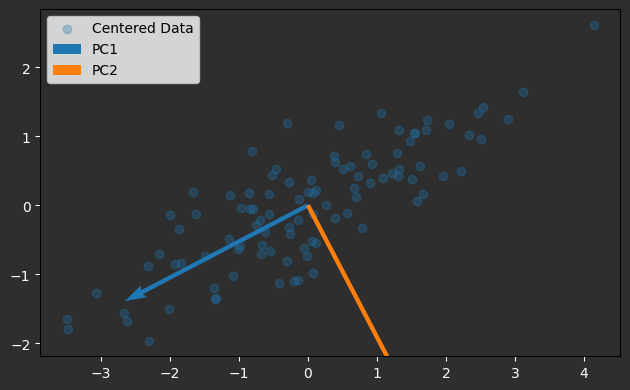

In [22]:
# Visualizing eigenvectors on the centered data
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, label="Centered Data")
origin = np.mean(X_centered, axis=0)

# Draw the first two eigenvectors
for i in range(2):
    vec = eig_vecs[:, i]
    ax.quiver(*origin, *vec * 3, angles='xy', scale_units='xy', scale=1, color=f"C{i}", label=f"PC{i + 1}")

ax.set_aspect('equal')
ax.tick_params(colors='white')

ax.legend()
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Principal-Components-as-Eigenvectors.png")

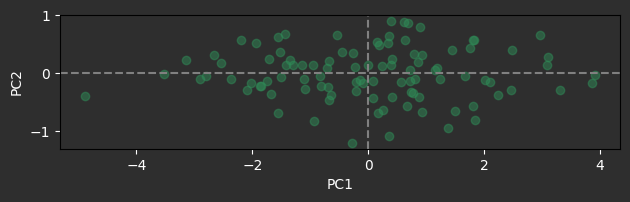

In [21]:
# Plot the projected data onto the first two principal components
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, color="seagreen")
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel("PC1", color='white')
ax.set_ylabel("PC2", color='white')
ax.tick_params(colors='white')
ax.set_aspect('equal')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Data Projected-onto-First-Two-Principal-Components.png")

<Figure size 640x480 with 0 Axes>

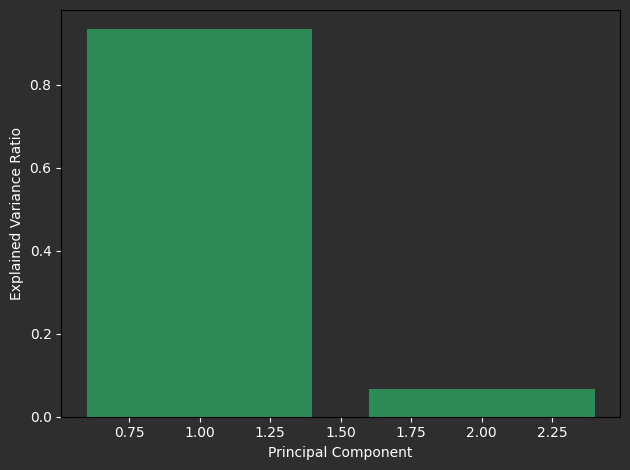

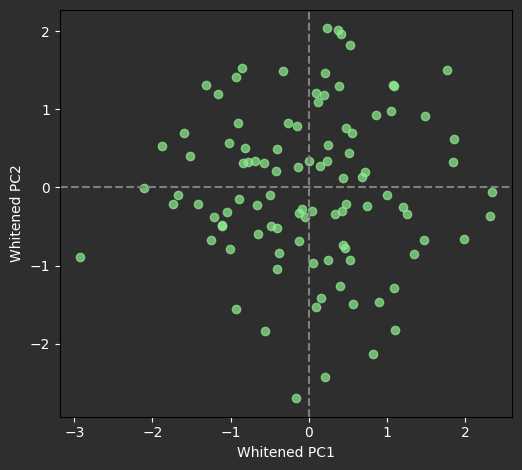

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data (as before)
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]
X = np.random.multivariate_normal(mean, cov, 100)
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

# Project and reconstruct using top 1 component
V_k = eig_vecs[:, :1]
Z = X_centered @ V_k
X_reconstructed = Z @ V_k.T

# Whitening
Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eig_vals))
X_white = X_centered @ eig_vecs @ Lambda_inv_sqrt

# ----------------- Slide 5: Scree Plot -----------------
plt.figure(facecolor='#2e2e2e')
fig1, ax1 = plt.subplots()
fig1.patch.set_facecolor('#2e2e2e')
ax1.set_facecolor('#2e2e2e')

explained_variance_ratio = eig_vals / np.sum(eig_vals)
ax1.bar(range(1, len(eig_vals) + 1), explained_variance_ratio, color='seagreen')
ax1.set_xlabel('Principal Component', color='white')
ax1.set_ylabel('Explained Variance Ratio', color='white')
ax1.tick_params(colors='white')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Scree-Plot.png")
# ----------------- Slide 6: Whitening -----------------
fig2, ax2 = plt.subplots()
fig2.patch.set_facecolor('#2e2e2e')
ax2.set_facecolor('#2e2e2e')

ax2.scatter(X_white[:, 0], X_white[:, 1], alpha=0.7, color='lightgreen')
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='gray', linestyle='--')
ax2.set_xlabel('Whitened PC1', color='white')
ax2.set_ylabel('Whitened PC2', color='white')
ax2.tick_params(colors='white')
ax2.set_aspect('equal')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/whitening.png")

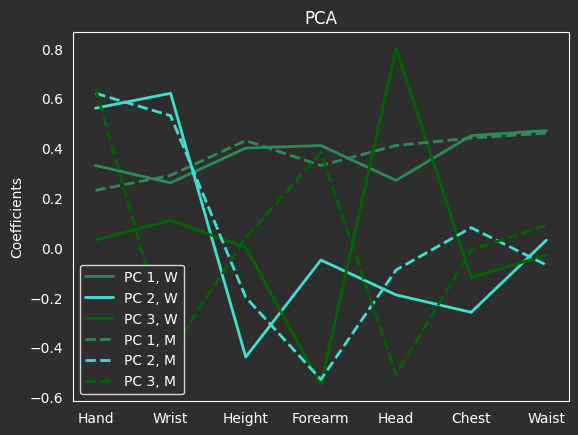

In [14]:
import matplotlib.pyplot as plt

# Define x and y values for each horizontal line
x1 = [0, 1, 2, 3, 4, 5, 6]
y1 = [0.33, 0.26, 0.40, 0.41, 0.27, 0.45, 0.47]

x2 = [0, 1, 2, 3, 4, 5, 6]
y2 = [0.56, 0.62, -0.44, -0.05, -0.19, -0.26, 0.03]

x3 = [0, 1, 2, 3, 4, 5, 6]
y3 = [0.03, 0.11, -0.00, -0.55, 0.80, -0.12, -0.03]

x4 = [0, 1, 2, 3, 4, 5, 6]
y4 = [0.23, 0.29, 0.43, 0.33, 0.41, 0.44, 0.46]

x5 = [0, 1, 2, 3, 4, 5, 6]
y5 = [0.62, 0.53, -0.20, -0.53, -0.09, 0.08, -0.07]

x6 = [0, 1, 2, 3, 4, 5, 6]
y6 = [0.64, -0.42, 0.04, 0.38, -0.51, -0.01, 0.09]

# Create the plot
# Create figure and axis
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Outer background
ax.set_facecolor('#2e2e2e')  # Plot area background

# Plot each line
plt.plot(x1, y1, linewidth=2, color='seagreen', label='PC 1, W')
plt.plot(x2, y2, label='PC 2, W', linewidth=2, color='turquoise')
plt.plot(x3, y3, label='PC 3, W', linewidth=2, color='darkgreen')

plt.plot(x4, y4, label='PC 1, M', linewidth=2, color='seagreen', linestyle='--')
plt.plot(x5, y5, label='PC 2, M', linewidth=2, color='turquoise', linestyle='--')
plt.plot(x6, y6, label='PC 3, M', linewidth=2, color='darkgreen', linestyle='--')

# Add labels and title
plt.ylabel('Coefficients', color='white')
tick_positions = [0, 1, 2, 3, 4, 5, 6]
tick_labels = ['Hand', 'Wrist', 'Height', 'Forearm', 'Head', 'Chest', 'Waist']
plt.xticks(tick_positions, tick_labels, color='white')  # Light tick labels

# Light y-ticks as well
plt.yticks(color='white')
plt.title('PCA')
# Legend with light text
legend = ax.legend(facecolor='#2e2e2e', edgecolor='white')
for text in legend.get_texts():
    text.set_color("white")
ax.grid(False)

# Show the plot
plt.savefig("../../output/figures/PCA_example.png")


RMS between Puerto Limón and Cristobal: 21.29
RMS between Puerto Limón and Balboa: 86.94
RMS between Cristobal and Balboa: 79.06


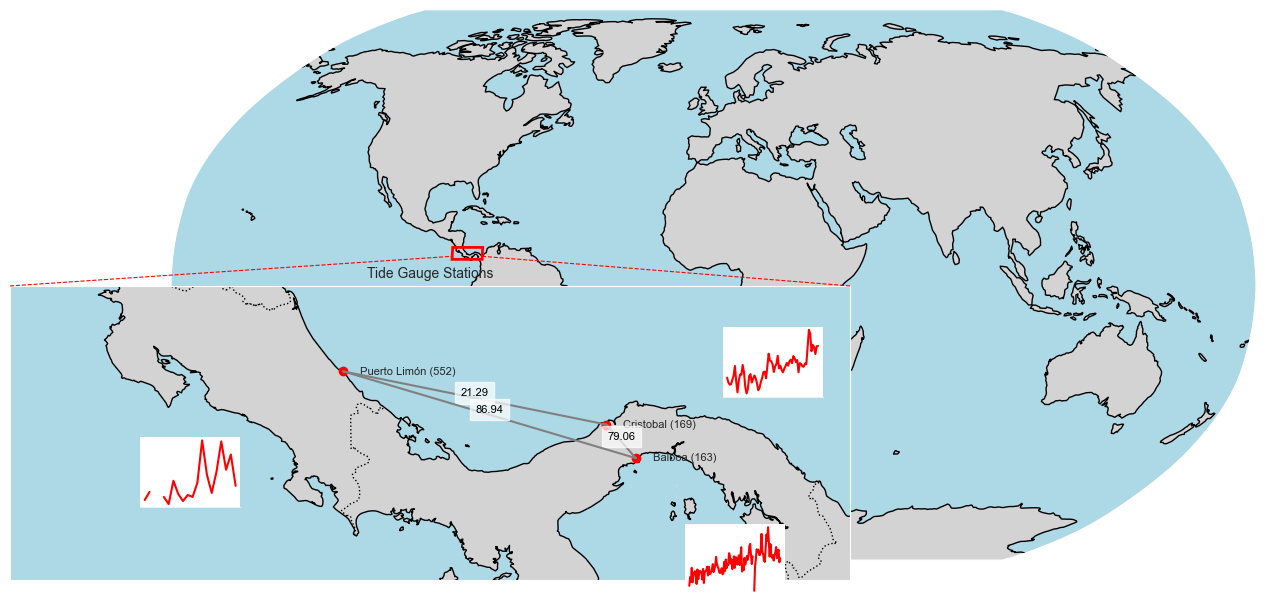

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
import numpy as np

# Define station metadata and dummy time series
# Puerto Limón: 552, Cristobal: 169, Balboa: 163
# read time series data from file
stations = {
    "Puerto Limón": {"coords": (-83.033, 9.983), "data": [], "dates": [], "color": "red",
                     "label": "Puerto Limón (552)", "id": "552"},
    "Cristobal": {"coords": (-79.900, 9.350), "data": [], "dates": [], "color": "red",
                  "label": "Cristobal (169)", "id": "169"},
    "Balboa": {"coords": (-79.550, 8.950), "data": [], "dates": [], "color": "red", "label": "Balboa (163)",
               "id": "163"},
}
for station, info in stations.items():
    # get time series data from file, data is stored in a file named <id>.rlrdata, only the second column contains the data
    file_path = f"../../data/rlr_annual/data/{info['id']}.rlrdata"
    data = []
    dates = []
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            # Read each line, and split the string by ;
            for line in f:
                parts = line.strip().split(';')
                if len(parts) > 1:  # Ensure there is a second column
                    try:
                        date = float(parts[0])  # First column is the date
                        value = float(parts[1])  # Convert the second column to float
                        dates.append(date)  # Store the date
                        # if value is -99999, skip it
                        if value != -99999:
                            data.append(value)
                        else:
                            data.append(np.nan)
                    except ValueError:
                        print(f"Warning: Could not convert value '{parts[1]}' to float in {station}.")
        info["data"] = data
        info["dates"] = dates
    else:
        print(f"Warning: Data file for {station} not found at {file_path}. Using dummy data.")
        info["data"] = np.random.normal(size=100)  # Dummy data if file not found
rms_between_stations = {}
# Calculate the RMS between each pair of stations
for station, info in stations.items():
    for other_station, other_info in stations.items():
        if station != other_station and (other_station, station) not in rms_between_stations.keys():
            # Calculate RMS between the two stations
            data1 = np.array(info["data"])
            data2 = np.array(other_info["data"])
            dates1 = np.array(info["dates"])
            dates2 = np.array(other_info["dates"])
            # find the common dates and calculate RMS only for those
            common_dates = set(dates1) & set(dates2)
            common_data1 = [data1[i] for i in range(len(info["dates"])) if info["dates"][i] in common_dates]
            common_data2 = [data2[i] for i in range(len(other_info["dates"])) if other_info["dates"][i] in common_dates]
            # Remove NaN values from both lists
            nan_positions1 = [i for i, x in enumerate(common_data1) if np.isnan(x)]
            nan_positions2 = [i for i, x in enumerate(common_data2) if np.isnan(x)]
            common_data1 = [x for i, x in enumerate(common_data1) if
                            i not in nan_positions1 and i not in nan_positions2]
            common_data2 = [x for i, x in enumerate(common_data2) if
                            i not in nan_positions2 and i not in nan_positions1]

            if len(common_data1) > 0 and len(common_data2) > 0:
                rms = np.sqrt(np.mean((np.array(common_data1) - np.array(common_data2)) ** 2))
                rms_between_stations[(station, other_station)] = rms
                print(f"RMS between {station} and {other_station}: {rms:.2f}")
            else:
                print(f"No common dates found between {station} and {other_station}. RMS cannot be calculated.")

# plot each stations time series on its own
if not os.path.exists('../../output/images/'):
    os.makedirs('../../output/images/')
for station, info in stations.items():
    fig, ax = plt.subplots()
    ax.plot(info["dates"], info["data"], label=station, color="black")
    ax.set_title(f"{station} Tide Gauge Time Series", fontsize=14)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Sea Level (m)", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.savefig(f"../../output/images/{station}.pdf")
    plt.close()

# Create figure
fig = plt.figure(figsize=(14, 8))

# Global map
ax_globe = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax_globe.set_global()
ax_globe.coastlines(resolution='110m')
ax_globe.add_feature(cfeature.LAND, facecolor='lightgray')
ax_globe.add_feature(cfeature.OCEAN, facecolor='lightblue')
# ax_globe.set_title("Global Context with Panama Region Inset", fontsize=14)

# Define Panama extent
panama_extent = [-87, -77, 7.5, 11]

# Draw red rectangle on global map for Panama region
region_rect = patches.Rectangle(
    (panama_extent[0], panama_extent[2]),
    panama_extent[1] - panama_extent[0],
    panama_extent[3] - panama_extent[2],
    linewidth=2, edgecolor='red', facecolor='none',
    transform=ccrs.PlateCarree(), zorder=5
)
ax_globe.add_patch(region_rect)

# Panama inset map
inset_pos = [0.01, 0.01, 0.6, 0.6]  # [left, bottom, width, height]
ax_inset = fig.add_axes(inset_pos, projection=ccrs.PlateCarree())
ax_inset.set_extent(panama_extent)
ax_inset.coastlines(resolution='10m')
ax_inset.add_feature(cfeature.BORDERS, linestyle=':')
ax_inset.add_feature(cfeature.LAND, facecolor='lightgray')
ax_inset.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax_inset.set_title("Tide Gauge Stations", fontsize=10)

# Plot each station and its time series panel with adjusted positions
for name, info in stations.items():
    lon, lat = info["coords"]

    # Station marker and label
    ax_inset.plot(lon, lat, 'o', color=info["color"], markersize=6, transform=ccrs.PlateCarree())
    ax_inset.text(lon + 0.2, lat, info["label"], fontsize=8, transform=ccrs.PlateCarree(), va='center')

    # Adjust time series panel position based on station
    if name == "Cristobal":
        # above and to the left
        bbox_anchor = (lon + 1.3, lat + 0.25)
    elif name == "Puerto Limón":
        # left and down
        bbox_anchor = (lon - 2.5, lat - 1.7)
    elif name == "Balboa":
        # a bit below
        bbox_anchor = (lon + 0.5, lat - 1.7)
    else:
        # default below
        bbox_anchor = (lon, lat - 3)

    # Time series panel at adjusted location
    ts_ax = inset_axes(ax_inset, width=1.0, height=0.7, loc='lower left',
                       bbox_to_anchor=bbox_anchor,
                       bbox_transform=ccrs.PlateCarree()._as_mpl_transform(ax_inset),
                       axes_class=plt.Axes)

    ts_ax.plot(info["data"], color=info["color"])
    ts_ax.set_xticks([])
    ts_ax.set_yticks([])
    ts_ax.set_facecolor('white')
    ts_ax.spines['top'].set_visible(False)
    ts_ax.spines['right'].set_visible(False)
    ts_ax.spines['left'].set_visible(False)
    ts_ax.spines['bottom'].set_linewidth(0.5)

# Connect tide gauge stations with red lines
station_coords = [info["coords"] for name, info in stations.items()]
station_coords_sorted = [stations["Puerto Limón"]["coords"], stations["Cristobal"]["coords"],
                         stations["Balboa"]["coords"]]

rms_sorted = [rms_between_stations[("Puerto Limón", "Cristobal")],
              rms_between_stations[("Cristobal", "Balboa")],
              rms_between_stations[("Puerto Limón", "Balboa")]]

station_coords_for_lines = station_coords_sorted
station_coords_for_lines.append(station_coords_sorted[0])  # Close the loop
lons, lats = zip(*station_coords_for_lines)
for i in range(len(lons) - 1):
    mid_lon = ((lons[i] + lons[i + 1]) / 2)
    mid_lat = ((lats[i] + lats[i + 1]) / 2)
    ax_inset.plot(lons[i:i + 2], lats[i:i + 2], color='grey', linewidth=1.5, linestyle='-',
                  transform=ccrs.PlateCarree(), zorder=3)
    ax_inset.text(mid_lon, mid_lat, round(rms_sorted[i], 2), transform=ccrs.PlateCarree(),
                  fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.7), ha='center', va='bottom',
                  rotation=0)

# Define pairs of (map corner lon/lat, inset corner relpos)
corner_pairs = [
    ((-87, 7.5), 'left'),  # bottom-left of red box → top-left of inset
    ((-77, 7.5), 'right'),  # bottom-right of red box → top-right of inset
]

for (lon, lat), inset_corner in corner_pairs:
    # Transform the global map point (lon/lat) to display coordinates
    disp_x, disp_y = ax_globe.projection.transform_point(lon, lat, ccrs.PlateCarree())
    globe_disp_coords = ax_globe.transData.transform((disp_x, disp_y))
    globe_fig_x = globe_disp_coords[0] / fig.bbox.width
    globe_fig_y = globe_disp_coords[1] / fig.bbox.height

    # Get inset corner in figure coords
    inset_box = ax_inset.get_position()
    if inset_corner == 'left':
        inset_fig_x = inset_box.x0
    else:  # 'right'
        inset_fig_x = inset_box.x1
    inset_fig_y = inset_box.y1  # top edge

    # Draw connecting line
    line = mlines.Line2D(
        [inset_fig_x, globe_fig_x],
        [inset_fig_y, globe_fig_y],
        transform=fig.transFigure, color='red', linestyle='--', linewidth=0.8
    )
    fig.lines.append(line)

# plt.show()
plt.savefig("../../output/images/globe_with_tide_gauges.pdf")

